# Code By *Karthikeya Maringanti*

**Input Data and converting the leaf images entirely into numpy array by reading the train file path directory**
# 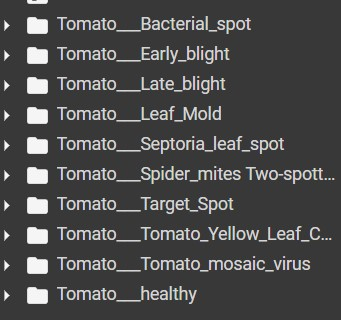


---




In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread
from skimage.transform import resize
import os
target=[]
images=[]
flat_data=[]

datadir='/content/drive/MyDrive/train'
categories=['Tomato___Bacterial_spot','Tomato___Early_blight','Tomato___healthy','Tomato___Late_blight','Tomato___Leaf_Mold','Tomato___Septoria_leaf_spot','Tomato___Spider_mites Two-spotted_spider_mite','Tomato___Target_Spot','Tomato___Tomato_mosaic_virus','Tomato___Tomato_Yellow_Leaf_Curl_Virus']
for category in categories:
  class_num=categories.index(category)
  path=os.path.join(datadir,category)
  for img in os.listdir(path):
    img_array=imread(os.path.join(path,img))
    img_resized=resize(img_array,(150,150,3))
    flat_data.append(img_resized.flatten())
    images.append(img_resized)
    target.append(class_num)

flat_data=np.array(flat_data)
target=np.array(target)
images=np.array(images)



# **Displaying the data which has been converted**

In [ ]:
flat_data

array([[0.58938998, 0.53056645, 0.55801743, ..., 0.58191791, 0.51917281,
        0.56231007],
       [0.69367808, 0.63485455, 0.64661926, ..., 0.55233464, 0.48958954,
        0.49351111],
       [0.52868183, 0.48162301, 0.52083869, ..., 0.68262623, 0.66301839,
        0.69046937],
       ...,
       [0.59443852, 0.61012479, 0.61404636, ..., 0.4       , 0.40089603,
        0.38431373],
       [0.56862745, 0.57254902, 0.58823529, ..., 0.30635294, 0.29458824,
        0.26664767],
       [0.68028044, 0.65764706, 0.6654902 , ..., 0.48792157, 0.44478431,
        0.46047059]])

# **Data Visualization of the categories of our dataset (Analysis)**

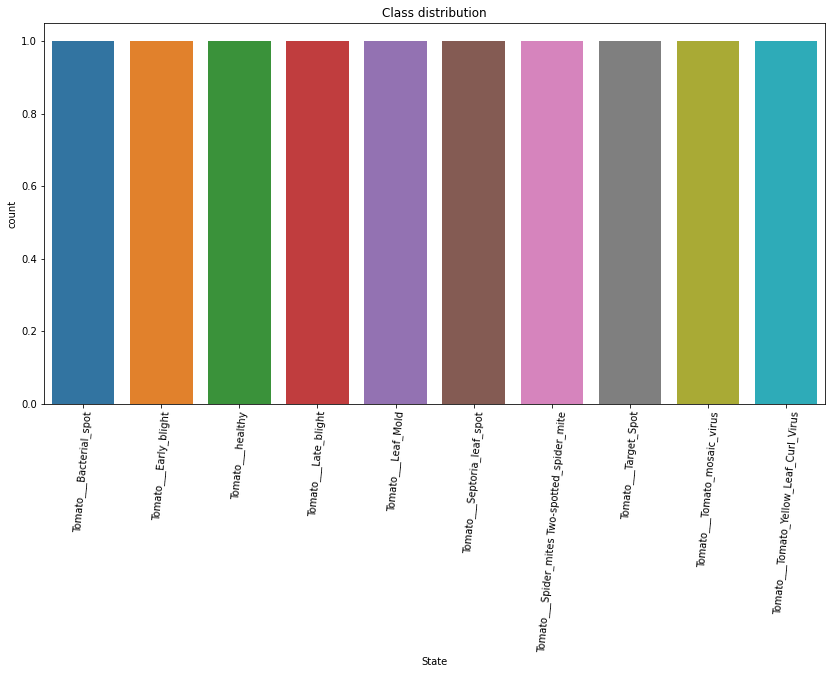

In [ ]:
import seaborn as sns
plt.figure(figsize=(14,7))
fig = sns.countplot(x=categories)
plt.xticks(rotation=85)
plt.title("Class distribution")
plt.xlabel('State')
plt.show()

# **Printing a leaf model from the training dataset**

(256, 256, 3)


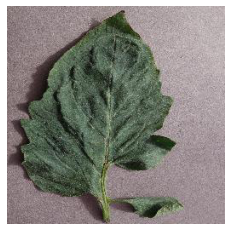

In [ ]:
img_path=r'/content/drive/MyDrive/train/Tomato___Target_Spot/0118c27a-f34a-41e1-8b2f-d2c564f83c5c___Com.G_TgS_FL 0013.JPG'
img=plt.imread(img_path)
print (img.shape)
plt.axis('off')
plt.imshow(img, cmap='gray')
plt.show()

# **Splitting the data into Train and test**

In [ ]:
#split data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(flat_data,target,test_size=0.3)

# **Linear Regression Algorithm Model**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
linear = LinearRegression()
linear.fit(x_train, y_train)
ols_predict = linear.predict(x_test)
ols_predict
# Constructing the confusion matrix for linear regression classifier


array([7.910167  , 8.61786213, 7.98271667, 9.13279431, 7.22020063,
       7.58492074, 6.67119807, 8.14478805, 8.        , 8.26191301,
       8.91552695, 7.53581383, 7.54321456, 8.5877981 , 8.4999736 ,
       6.93376631, 6.81800715, 7.06734182, 7.97509581, 9.24978032,
       7.22746109, 7.5571881 , 8.80580785, 9.67807938, 8.3804154 ,
       8.38496446, 8.18327486, 8.12080507, 8.07966049, 7.95120458,
       7.94189946, 7.00714103, 8.40944724, 8.44120049, 8.130267  ,
       7.86852152, 8.68257051, 8.78810632, 7.91144486, 7.9984451 ,
       8.82275278, 7.14368552, 8.41275954, 7.91662142, 7.67314448,
       8.00009393, 9.16659285, 8.2203884 , 6.92328468, 7.61888771,
       9.14883407, 7.47300442, 8.00187696, 9.00248625, 8.00965513,
       8.59522596, 9.57602834, 9.0719553 , 8.26262727, 7.20660453,
       7.18382781, 8.69995513, 8.15349661, 8.43409429, 8.33904505,
       7.93670215, 7.57874798, 6.69282   , 7.31141079, 8.62531043,
       7.50898691, 8.60746156, 7.65930833, 7.27168419, 8.92925

# **Checking Score of Linear Regression Model with r2_score function**

In [ ]:
r2_score(ols_predict, y_test)

0.6077200873411993

# ***Similarly***

# **Logistic Regression Model Algorithm Score Check**

In [ ]:
#Fitting Logistic Regression to the training set  
from sklearn.linear_model import LogisticRegression  
classifier= LogisticRegression(random_state=0)  
classifier.fit(x_train, y_train)  
#Predicting the test set result  
y_pred= classifier.predict(x_test)  
y_pred
r2_score(y_pred, y_test)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


0.9030648383220189

# **Now performing SVM(Support Vector Machine) Algorithm**

In [ ]:
#Fitting Logistic Regression to the training set  
from sklearn.svm import SVC
svclassifier = SVC(kernel='linear')
svclassifier.fit(x_train, y_train)

#Predicting the test set result  
y_pred_S= classifier.predict(x_test)  
y_pred_S
r2_score(y_pred_S, y_test)

0.9030648383220189

# **Performing DecisionTreeClassifier Algorithm Model**

In [ ]:
#Fitting Decision Tree classifier to the training set  
from sklearn.tree import DecisionTreeClassifier  
classifier_dt= DecisionTreeClassifier(criterion='entropy', random_state=0)  
classifier_dt.fit(x_train, y_train)
#Predicting the test set result  
y_pred_dt= classifier.predict(x_test)
y_pred_dt
#Creating the Confusion matrix  
from sklearn.metrics import confusion_matrix  
cm= confusion_matrix(y_test, y_pred_dt) 
r2_score(y_pred_dt, y_test)

0.9030648383220189

# **Performing RandomForestClassifier Algorithm Model** *with 200 estimations*

In [ ]:
#Fitting Decision Tree classifier to the training set  
from sklearn.ensemble import RandomForestClassifier  
classifier_rf= RandomForestClassifier(n_estimators= 200, criterion="entropy")  
classifier_rf.fit(x_train, y_train)
y_pred_rf= classifier_rf.predict(x_test) 
#Creating the Confusion matrix  
from sklearn.metrics import confusion_matrix  
cm_rf= confusion_matrix(y_test, y_pred_rf) 
r2_score(y_pred_rf, y_test)

0.7544403629193903

# **Performing Lasso Algorithm Model** with *alpha approximation = 0.01*

---



In [ ]:
from sklearn.linear_model import Lasso
model_lasso = Lasso(alpha=0.01)
model_lasso.fit(x_train, y_train)
# pred_train_lasso= model_lasso.predict(x_train)
pred_lasso= model_lasso.predict(x_test)
print(np.sqrt(mean_squared_error(pred_lasso, y_test)))
r2_score( pred_lasso, y_test)

0.5044920239947921


0.07523268790768944

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Performing Ridge Algorithm Model** with *alpha approximation = 0.5*


In [ ]:
from sklearn.linear_model import Ridge
model_r = Ridge(alpha = 0.5, normalize = False, tol = 0.01, \
              solver ='auto', random_state = 42)
model_r.fit(x_train, y_train)
  
# predicting the y_test
y_pred_r = model_r.predict(x_test)
  
# finding score for our model
r2_score(y_pred_r, y_test)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_base.py:155: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2. Please leave the normalize parameter to its default value to silence this warning. The default behavior of this estimator is to not do any normalization. If normalization is needed please use sklearn.preprocessing.StandardScaler instead.
  FutureWarning,


0.60824473527948